In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
from pathlib import Path

In [4]:
DATA_DIR = Path("data")
CUSTOMER_PATH = DATA_DIR / "customer_journey.parquet"
customer_journey = pd.read_parquet(CUSTOMER_PATH)

In [5]:
customer_journey["timestamp_utc"] = pd.to_datetime(
    customer_journey["timestamp_utc"], errors="coerce", utc=True
)

In [6]:
orders = customer_journey[
    (customer_journey["channel"] == "RETAIL") &
    (customer_journey["event_type"] == "Order")
][["customer_id", "timestamp_utc", "sales", "quantity"]].rename(columns={"timestamp_utc": "order_time"}).copy()

exposures = customer_journey[
    customer_journey["event_type"] == "exposure"
][["customer_id", "timestamp_utc", "channel", "cost"]].rename(columns={"timestamp_utc": "expo_time"}).copy()


# BLOC 1 — Exposition → Conversion dans une fenêtre (ici, 30 jours)


Pour chaque order, on veut savoir s’il existe au moins une exposure entre order_time - window et order_time.

On fait ça via une astuce robuste :

On crée un rang cumulatif expo_rank par customer

on récupère le rang du dernier expo avant order_time (rank_right) et le rang du dernier expo avant window_start (rank_left)

nb_exposures_window = rank_right - rank_left

In [15]:
WINDOW_DAYS = 30
window = pd.Timedelta(days=WINDOW_DAYS)

# --- 1) Customer_id robuste (peut être alphanumérique)
# On le met en string (category optionnel) pour by=customer_id
customer_journey["customer_id"] = customer_journey["customer_id"].astype("string")

# --- 2) Extract minimal tables (colonnes minimales => perf)
orders = customer_journey[
    (customer_journey["channel"] == "RETAIL") &
    (customer_journey["event_type"] == "Order")
][["customer_id", "timestamp_utc", "sales", "quantity"]].rename(columns={"timestamp_utc": "order_time"}).copy()

exposures = customer_journey[
    (customer_journey["event_type"] == "exposure") &
    (customer_journey["channel"].isin(["TV", "PROGRAMMATIC"]))
][["customer_id", "timestamp_utc"]].rename(columns={"timestamp_utc": "expo_time"}).copy()

# --- 3) Drop NaT (merge_asof ne supporte pas bien les NaT)
orders = orders.dropna(subset=["order_time", "customer_id"]).copy()
exposures = exposures.dropna(subset=["expo_time", "customer_id"]).copy()

# --- 4) Préparer le rang cumulé des expositions par client
# (IMPORTANT: trier par client puis temps pour que le cumcount ait du sens)
exposures = exposures.sort_values(["customer_id", "expo_time"]).reset_index(drop=True)
expo_ranked = exposures[["customer_id", "expo_time"]].copy()
expo_ranked["expo_rank"] = expo_ranked.groupby("customer_id").cumcount() + 1

# --- 5) Début de fenêtre pour chaque order
orders_w = orders.copy()
orders_w["window_start"] = orders_w["order_time"] - window

# --- 6) merge_asof exige un tri global par clé temporelle (puis customer_id)
orders_w_order_sorted = orders_w.sort_values(["order_time", "customer_id"]).reset_index(drop=True)
orders_w_start_sorted = orders_w.sort_values(["window_start", "customer_id"]).reset_index(drop=True)
expo_ranked_sorted = expo_ranked.sort_values(["expo_time", "customer_id"]).reset_index(drop=True)

# --- 7) Rank du dernier expo <= order_time
right = pd.merge_asof(
    orders_w_order_sorted,
    expo_ranked_sorted,
    left_on="order_time",
    right_on="expo_time",
    by="customer_id",
    direction="backward",
    allow_exact_matches=True
).rename(columns={"expo_rank": "rank_right"})[
    ["customer_id", "order_time", "sales", "quantity", "window_start", "rank_right"]
]

# --- 8) Rank du dernier expo <= window_start
left = pd.merge_asof(
    orders_w_start_sorted[["customer_id", "order_time", "window_start"]],
    expo_ranked_sorted,
    left_on="window_start",
    right_on="expo_time",
    by="customer_id",
    direction="backward",
    allow_exact_matches=True
).rename(columns={"expo_rank": "rank_left"})[
    ["customer_id", "order_time", "rank_left"]
]

# --- 9) Assemblage + calcul du nb d'expos dans la fenêtre
order_expo_window = right.merge(left, on=["customer_id", "order_time"], how="left")

order_expo_window["rank_right"] = order_expo_window["rank_right"].fillna(0).astype("int64")
order_expo_window["rank_left"]  = order_expo_window["rank_left"].fillna(0).astype("int64")

col_nb = f"nb_exposures_{WINDOW_DAYS}d"
col_flag = f"has_exposure_{WINDOW_DAYS}d"

order_expo_window[col_nb] = order_expo_window["rank_right"] - order_expo_window["rank_left"]
order_expo_window[col_flag] = order_expo_window[col_nb] > 0

# --- 10) Sanity checks (rapides)
assert (order_expo_window[col_nb] >= 0).all(), "Negative exposures in window: check sorting / timestamps"

coverage = order_expo_window[col_flag].mean()
print(f"Coverage (>=1 exposure in {WINDOW_DAYS}d): {coverage:.3f}")
print(order_expo_window[col_nb].describe(percentiles=[0.5, 0.9, 0.99]))

order_expo_window.head()



Coverage (>=1 exposure in 30d): 0.161
count    1.410988e+06
mean     3.997327e-01
std      1.641440e+00
min      0.000000e+00
50%      0.000000e+00
90%      1.000000e+00
99%      8.000000e+00
max      7.700000e+01
Name: nb_exposures_30d, dtype: float64


,customer_id,order_time,sales,quantity,window_start,rank_right,rank_left,nb_exposures_30d,has_exposure_30d
0,rektegFh4TJ1LDtTth,2024-01-01 00:00:12+00:00,18.990000,1.0,2023-12-02 00:00:12+00:00,0,0,0,False
1,reW7Y1G1GC4A7KNHwL,2024-01-01 00:00:24+00:00,38.880001,1.0,2023-12-02 00:00:24+00:00,0,0,0,False
2,reOrz1B6zmm64cVhF5,2024-01-01 00:00:30+00:00,20.480000,1.0,2023-12-02 00:00:30+00:00,0,0,0,False
3,reC1u1pLxiCmxBCE6v,2024-01-01 00:00:46+00:00,7.490000,1.0,2023-12-02 00:00:46+00:00,0,0,0,False
4,reEpFTpAK2Na7MPEwA,2024-01-01 00:00:52+00:00,116.639999,3.0,2023-12-02 00:00:52+00:00,0,0,0,False


## KPI Bloc 1

In [16]:
share_orders_exposed = order_expo_window["has_exposure_30d"].mean()
print("Share of orders with exposure in last 30 days:")
print(share_orders_exposed)


Share of orders with exposure in last 30 days:
0.1612912370622571


# Bloc 2 : Last Touch in the window

Pour chaque order :

- prendre la dernière exposure avant l’order (via merge_asof)

- vérifier qu’elle est bien dans les 30 jours

- attribuer l’order au channel de cette dernière exposure

In [17]:
# --- Orders (Retail conversions)
orders_lt = customer_journey[
    (customer_journey["channel"] == "RETAIL") &
    (customer_journey["event_type"] == "Order")
][["customer_id", "timestamp_utc", "sales", "quantity"]].rename(columns={"timestamp_utc": "order_time"}).copy()

# --- Exposures (Media)
exposures_lt = customer_journey[
    (customer_journey["event_type"] == "exposure") &
    (customer_journey["channel"].isin(["TV", "PROGRAMMATIC"]))
][["customer_id", "timestamp_utc", "channel", "cost"]].rename(columns={"timestamp_utc": "expo_time"}).copy()

# --- Drop NaT
orders_lt = orders_lt.dropna(subset=["customer_id", "order_time"])
exposures_lt = exposures_lt.dropna(subset=["customer_id", "expo_time"])

# --- merge_asof requires sorting by time then customer_id
orders_lt = orders_lt.sort_values(["order_time", "customer_id"]).reset_index(drop=True)
exposures_lt = exposures_lt.sort_values(["expo_time", "customer_id"]).reset_index(drop=True)

# --- Last touch
last_touch = pd.merge_asof(
    orders_lt,
    exposures_lt,
    left_on="order_time",
    right_on="expo_time",
    by="customer_id",
    direction="backward",
    allow_exact_matches=True
)

last_touch["delta"] = last_touch["order_time"] - last_touch["expo_time"]
last_touch["days_before_order"] = last_touch["delta"].dt.total_seconds() / 86400

# --- Filter window
last_touch["is_in_window"] = last_touch["delta"].between(pd.Timedelta(0), window)
last_touch_in_window = last_touch[last_touch["is_in_window"]].copy()

# Quick outputs
print("Coverage last-touch in window:", len(last_touch_in_window) / len(orders_lt))
last_touch_in_window["channel"].value_counts(normalize=True)


Coverage last-touch in window: 0.16129699876956924


channel
PROGRAMMATIC    0.903393
TV              0.096607
Name: proportion, dtype: float64

In [18]:
attr_kpis = (
    last_touch_in_window
    .groupby("channel")
    .agg(
        nb_orders=("order_time", "count"),
        revenue=("sales", "sum"),
        avg_order_value=("sales", "mean"),
        median_days_before=("days_before_order", "median"),
        last_touch_cost=("cost", "sum")
    )
    .assign(
        cpa_last_touch=lambda d: d["last_touch_cost"] / d["nb_orders"],
        roas_last_touch=lambda d: d["revenue"] / d["last_touch_cost"]
    )
    .sort_values("nb_orders", ascending=False)
)

attr_kpis


,nb_orders,revenue,avg_order_value,median_days_before,last_touch_cost,cpa_last_touch,roas_last_touch
channel,,,,,,,
PROGRAMMATIC,205587,8939044.0,43.480591,6.273773,3.428320e+08,1667.576144,0.026074
TV,21985,945800.5,43.020264,12.403611,5.112634e+07,2325.510000,0.018499


In [13]:
# On refait le merge_asof en gardant campaign_name (uniquement programmatic)
exposures_lt2 = customer_journey[
    customer_journey["event_type"] == "exposure"
][["customer_id","timestamp_utc","channel","cost","campaign_name"]].rename(columns={"timestamp_utc":"expo_time"}).dropna(subset=["expo_time"])

exposures_lt2 = exposures_lt2.sort_values(["expo_time","customer_id"]).reset_index(drop=True)

last_touch2 = pd.merge_asof(
    orders_lt[["customer_id","order_time","sales"]],
    exposures_lt2[["customer_id","expo_time","channel","cost","campaign_name"]],
    left_on="order_time",
    right_on="expo_time",
    by="customer_id",
    direction="backward"
)

last_touch2["delta"] = last_touch2["order_time"] - last_touch2["expo_time"]
last_touch2 = last_touch2[last_touch2["delta"].between(pd.Timedelta(0), window)]

# Top campagnes en last-touch
last_touch2[last_touch2["channel"]=="PROGRAMMATIC"]["campaign_name"].value_counts().head(15)


campaign_name
Retargeting    180329
Contextual      25258
Name: count, dtype: int64

C:\Users\adamc\AppData\Local\Temp\ipykernel_21960\496836190.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20")


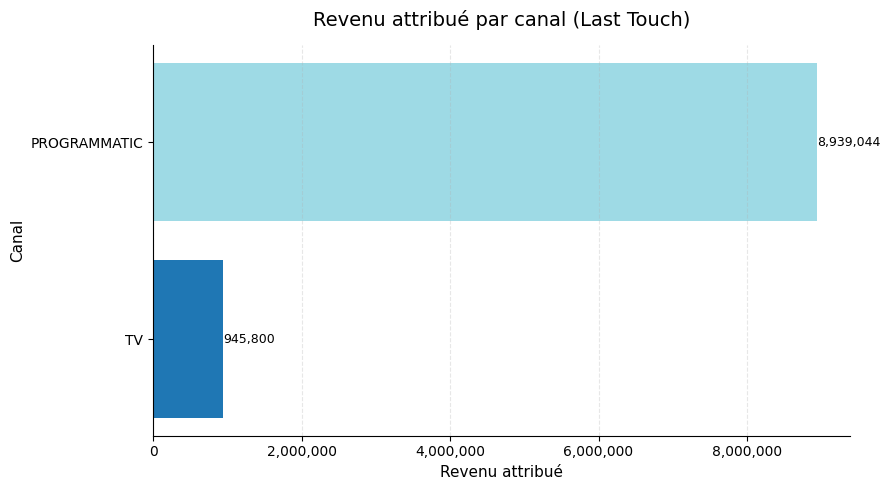

In [39]:
# =========================
# Visualisation — Bloc 2
# Revenu attribué par channel (Last Touch)
# =========================

# --- Sélection du dataframe last touch
if "last_touch_in_window" in globals():
    df2 = last_touch_in_window.copy()
elif "last_touch2" in globals():
    df2 = last_touch2.copy()
else:
    raise NameError("Je ne trouve ni `last_touch_in_window` ni `last_touch2`.")

# --- Agrégation : revenu attribué par channel
by_channel = (
    df2.dropna(subset=["channel", "sales"])
       .groupby("channel", as_index=False)
       .agg(revenue=("sales", "sum"))
       .sort_values("revenue", ascending=True)
)

# --- Palette de couleurs (une couleur par channel)
cmap = plt.cm.get_cmap("tab20")
colors = cmap(np.linspace(0, 1, len(by_channel)))

# --- Graphique
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    by_channel["channel"],
    by_channel["revenue"],
    color=colors
)

# --- Titres & labels
ax.set_title("Revenu attribué par canal (Last Touch)", fontsize=14, pad=14)
ax.set_xlabel("Revenu attribué", fontsize=11)
ax.set_ylabel("Canal", fontsize=11)

# --- Format axe X (séparateurs de milliers)
ax.get_xaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:,.0f}")
)

# --- Labels de valeur au bout de chaque barre
for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        ha="left",
        fontsize=9
    )

# --- Nettoyage visuel
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
share_orders_exposed = order_expo_window["has_exposure_30d"].mean()
print("Share of orders with exposure in last 30 days:")
print(share_orders_exposed)


Share of orders with exposure in last 30 days:
0.1612912370622571


# Bloc 3 : Capping

In [19]:
order_expo_window["nb_exposures_30d"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)


count    1.410988e+06
mean     3.997327e-01
std      1.641440e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      1.000000e+00
95%      2.000000e+00
99%      8.000000e+00
max      7.700000e+01
Name: nb_exposures_30d, dtype: float64

In [21]:
bins = [-1, 0, 1, 3, 5, 10, 20, 50, 10**9]
labels = ["0", "1", "2-3", "4-5", "6-10", "11-20", "21-50", "50+"]

df_cap = order_expo_window[[
    "customer_id",
    "order_time",
    "nb_exposures_30d",
    "sales"
]].copy()

df_cap["expo_bucket"] = pd.cut(
    df_cap["nb_exposures_30d"],
    bins=bins,
    labels=labels
)

df_cap.head()


,customer_id,order_time,nb_exposures_30d,sales,expo_bucket
0,rektegFh4TJ1LDtTth,2024-01-01 00:00:12+00:00,0,18.990000,0
1,reW7Y1G1GC4A7KNHwL,2024-01-01 00:00:24+00:00,0,38.880001,0
2,reOrz1B6zmm64cVhF5,2024-01-01 00:00:30+00:00,0,20.480000,0
3,reC1u1pLxiCmxBCE6v,2024-01-01 00:00:46+00:00,0,7.490000,0
4,reEpFTpAK2Na7MPEwA,2024-01-01 00:00:52+00:00,0,116.639999,0


In [22]:
cap_summary = (
    df_cap
    .groupby("expo_bucket", observed=True)
    .agg(
        nb_orders=("order_time", "count"),
        revenue=("sales", "sum"),
        avg_revenue=("sales", "mean"),
        median_exposures=("nb_exposures_30d", "median")
    )
    .assign(
        share_orders=lambda d: d["nb_orders"] / d["nb_orders"].sum(),
        share_revenue=lambda d: d["revenue"] / d["revenue"].sum()
    )
    .reset_index()
)

cap_summary


,expo_bucket,nb_orders,revenue,avg_revenue,median_exposures,share_orders,share_revenue
0,0,1183408,5.131158e+07,43.359161,0.0,0.838709,0.838469
1,1,146748,6.264666e+06,42.689957,1.0,0.104004,0.102369
2,2-3,42039,1.862355e+06,44.300644,2.0,0.029794,0.030432
3,4-5,14542,6.661594e+05,45.809338,4.0,0.010306,0.010886
4,6-10,15500,6.966621e+05,44.945938,7.0,0.010985,0.011384
5,11-20,7449,3.359697e+05,45.102654,13.0,0.005279,0.005490
6,21-50,1288,5.878693e+04,45.642025,23.0,0.000913,0.000961
7,50+,14,5.639400e+02,40.281429,57.0,0.000010,0.000009


In [23]:
cap_summary["cum_share_orders"] = cap_summary["share_orders"].cumsum()
cap_summary["cum_share_revenue"] = cap_summary["share_revenue"].cumsum()

cap_summary[[
    "expo_bucket",
    "cum_share_orders",
    "cum_share_revenue"
]]


,expo_bucket,cum_share_orders,cum_share_revenue
0,0,0.838709,0.838469
1,1,0.942712,0.940838
2,2-3,0.972506,0.971271
3,4-5,0.982813,0.982156
4,6-10,0.993798,0.993540
5,11-20,0.999077,0.999030
6,21-50,0.999990,0.999991
7,50+,1.000000,1.000000


## Capping par canal

In [33]:
# --- Bloc 3 : Capping (corrigé + gestion explicite des NaN de channel)

bins = [-1, 0, 1, 3, 5, 10, 20, 50, 10**9]
labels = ["0", "1", "2-3", "4-5", "6-10", "11-20", "21-50", "50+"]

# Base capping au niveau commande
df_cap = order_expo_window[[
    "customer_id",
    "order_time",
    "nb_exposures_30d",
    "sales"
]].copy()

# Bucket d'expositions (catégorie ordonnée => cumuls cohérents)
df_cap["expo_bucket"] = pd.cut(
    df_cap["nb_exposures_30d"],
    bins=bins,
    labels=labels,
    ordered=True
)

# Ajout du "last touch channel" (LEFT JOIN => normal d'avoir des NaN)
df_cap = df_cap.merge(
    last_touch_in_window[["customer_id", "order_time", "channel"]],
    on=["customer_id", "order_time"],
    how="left"
)

# On rend explicites les commandes non attribuées à un canal
df_cap["channel"] = df_cap["channel"].fillna("No channel / Organic")

# Résumé global (tous canaux confondus)
cap_summary = (
    df_cap
    .groupby("expo_bucket", observed=True)
    .agg(
        nb_orders=("order_time", "count"),
        revenue=("sales", "sum"),
        avg_revenue=("sales", "mean"),
        median_exposures=("nb_exposures_30d", "median")
    )
    .assign(
        share_orders=lambda d: d["nb_orders"] / d["nb_orders"].sum(),
        share_revenue=lambda d: d["revenue"] / d["revenue"].sum()
    )
    .reset_index()
)

# Résumé par channel + bucket (avec cumuls dans le bon ordre)
cap_by_channel = (
    df_cap
    .groupby(["channel", "expo_bucket"], observed=True)
    .agg(
        nb_orders=("order_time", "count"),
        revenue=("sales", "sum")
    )
    .reset_index()
    .sort_values(["channel", "expo_bucket"])
    .groupby("channel", group_keys=False)
    .apply(lambda d: d.assign(
        share_orders=d["nb_orders"] / d["nb_orders"].sum(),
        cum_share_orders=d["nb_orders"].cumsum() / d["nb_orders"].sum()
    ))
)

cap_summary, cap_by_channel


C:\Users\adamc\AppData\Local\Temp\ipykernel_21960\3879387843.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.assign(


(  expo_bucket  nb_orders       revenue  avg_revenue  median_exposures  \
 0           0    1183408  5.131158e+07    43.359161               0.0   
 1           1     146764  6.265301e+06    42.689632               1.0   
 2         2-3      42039  1.862355e+06    44.300644               2.0   
 3         4-5      14542  6.661594e+05    45.809338               4.0   
 4        6-10      15500  6.966621e+05    44.945938               7.0   
 5       11-20       7449  3.359697e+05    45.102654              13.0   
 6       21-50       1288  5.878693e+04    45.642025              23.0   
 7         50+         14  5.639400e+02    40.281429              57.0   
 
    share_orders  share_revenue  
 0      0.838699       0.838460  
 1      0.104014       0.102379  
 2      0.029794       0.030432  
 3      0.010306       0.010885  
 4      0.010985       0.011384  
 5      0.005279       0.005490  
 6      0.000913       0.000961  
 7      0.000010       0.000009  ,
                  channel

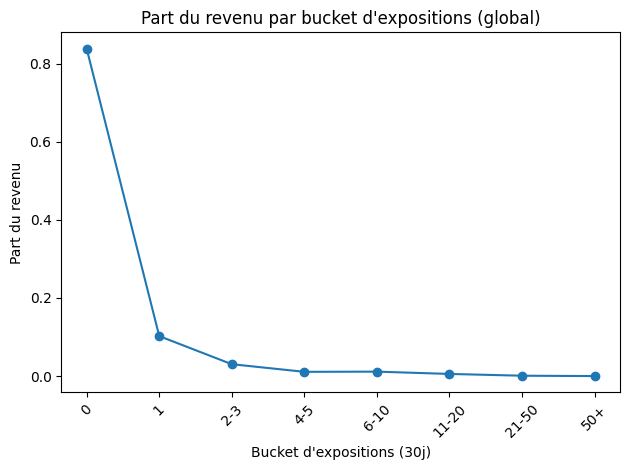

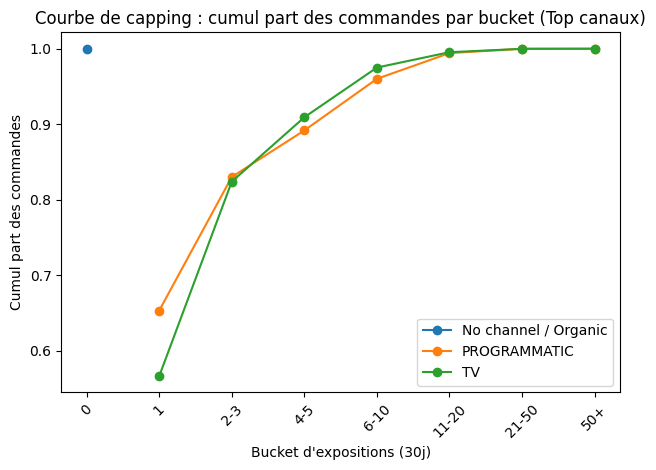

C:\Users\adamc\AppData\Local\Temp\ipykernel_21960\3945941233.py:40: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = cap_by_channel.pivot_table(


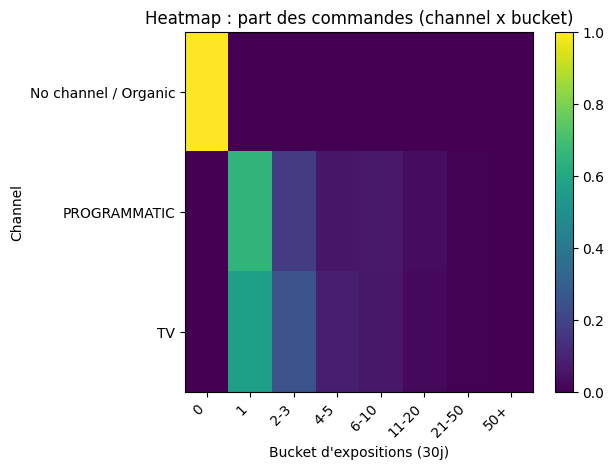

In [42]:
# --- Visualisation des résultats de capping (cap_summary + cap_by_channel)

import matplotlib.pyplot as plt

# 1) Vue globale : part du revenu par bucket
fig, ax = plt.subplots()
ax.plot(cap_summary["expo_bucket"].astype(str), cap_summary["share_revenue"], marker="o")
ax.set_title("Part du revenu par bucket d'expositions (global)")
ax.set_xlabel("Bucket d'expositions (30j)")
ax.set_ylabel("Part du revenu")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2) Par channel : courbe de "capping" = cumul part des commandes par bucket
#    (utile pour voir à partir de quel bucket on couvre X% des commandes par canal)
channels_to_plot = (
    cap_by_channel.groupby("channel")["nb_orders"].sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

fig, ax = plt.subplots()
for ch in channels_to_plot:
    tmp = cap_by_channel[cap_by_channel["channel"] == ch].sort_values("expo_bucket")
    ax.plot(tmp["expo_bucket"].astype(str), tmp["cum_share_orders"], marker="o", label=ch)

ax.set_title("Courbe de capping : cumul part des commandes par bucket (Top canaux)")
ax.set_xlabel("Bucket d'expositions (30j)")
ax.set_ylabel("Cumul part des commandes")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# 3) Heatmap simple (sans seaborn) : part des commandes par channel x bucket
#    (pratique pour repérer les canaux avec beaucoup d'expositions élevées)
pivot = cap_by_channel.pivot_table(
    index="channel",
    columns="expo_bucket",
    values="share_orders",
    aggfunc="sum",
    fill_value=0
)

# On limite aux mêmes canaux pour rester lisible
pivot = pivot.loc[channels_to_plot]

fig, ax = plt.subplots()
im = ax.imshow(pivot.values, aspect="auto")
ax.set_title("Heatmap : part des commandes (channel x bucket)")
ax.set_xlabel("Bucket d'expositions (30j)")
ax.set_ylabel("Channel")
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels([str(c) for c in pivot.columns], rotation=45, ha="right")
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels(pivot.index)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
